In [61]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [62]:
lena = cv2.imread('../assets/Lena.jpg', 0)

cv2.imshow('Lena', lena)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [63]:
def gaussianFunction(x,y,sigma):
    return (1/(2*np.pi*sigma**2))*np.exp(-(x**2 + y**2) /(2*sigma**2))

In [64]:
def gaussianKernel_x(size, sigma):

    k = size // 2
    coords = np.arange(-k, k + 1)
    x,y = np.meshgrid(coords, coords)
    gaussval = gaussianFunction(x, y, sigma)
    kernel = -(x / sigma**2) * gaussval
    kernel /= np.sum(kernel)

    return kernel

In [65]:
gaussian_kernel_x=gaussianKernel_x(7, 1)
print(gaussian_kernel_x)

[[-2.79691995e+12 -2.27156403e+13 -5.09022183e+13  0.00000000e+00
   5.09022183e+13  2.27156403e+13  2.79691995e+12]
 [-3.40734604e+13 -2.76733150e+14 -6.20115968e+14  0.00000000e+00
   6.20115968e+14  2.76733150e+14  3.40734604e+13]
 [-1.52706655e+14 -1.24023194e+15 -2.77916695e+15  0.00000000e+00
   2.77916695e+15  1.24023194e+15  1.52706655e+14]
 [-2.51770710e+14 -2.04479677e+15 -4.58207167e+15  0.00000000e+00
   4.58207167e+15  2.04479677e+15  2.51770710e+14]
 [-1.52706655e+14 -1.24023194e+15 -2.77916695e+15  0.00000000e+00
   2.77916695e+15  1.24023194e+15  1.52706655e+14]
 [-3.40734604e+13 -2.76733150e+14 -6.20115968e+14  0.00000000e+00
   6.20115968e+14  2.76733150e+14  3.40734604e+13]
 [-2.79691995e+12 -2.27156403e+13 -5.09022183e+13  0.00000000e+00
   5.09022183e+13  2.27156403e+13  2.79691995e+12]]


In [66]:
def gaussianKernel_y(size, sigma):
   
    k = size // 2
    coords = np.arange(-k, k + 1)
    x,y = np.meshgrid(coords, coords)
    gaussval = gaussianFunction(x, y, sigma)
    kernel = -(y / sigma**2) * gaussval
    kernel /= np.sum(kernel)

    return kernel

In [67]:
gaussian_kernel_y=gaussianKernel_y(7, 1)
print(gaussian_kernel_y)

[[ 1.71072676e+12  2.08409184e+13  9.34025163e+13  1.53994715e+14
   9.34025163e+13  2.08409184e+13  1.71072676e+12]
 [ 1.38939456e+13  1.69262909e+14  7.58583727e+14  1.25069313e+15
   7.58583727e+14  1.69262909e+14  1.38939456e+13]
 [ 3.11341721e+13  3.79291864e+14  1.69986820e+15  2.80260886e+15
   1.69986820e+15  3.79291864e+14  3.11341721e+13]
 [-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]
 [-3.11341721e+13 -3.79291864e+14 -1.69986820e+15 -2.80260886e+15
  -1.69986820e+15 -3.79291864e+14 -3.11341721e+13]
 [-1.38939456e+13 -1.69262909e+14 -7.58583727e+14 -1.25069313e+15
  -7.58583727e+14 -1.69262909e+14 -1.38939456e+13]
 [-1.71072676e+12 -2.08409184e+13 -9.34025163e+13 -1.53994715e+14
  -9.34025163e+13 -2.08409184e+13 -1.71072676e+12]]


In [68]:
convo_x = cv2.filter2D(lena, cv2.CV_32F, gaussian_kernel_x)
norm_x = cv2.normalize(convo_x, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

In [69]:
cv2.imshow('Convolution X', convo_x)
cv2.imshow('Normalized X', norm_x)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [70]:
convo_y = cv2.filter2D(lena, cv2.CV_32F, gaussian_kernel_y)
norm_y = cv2.normalize(convo_y, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

In [71]:
cv2.imshow('Convolution Y', convo_y)
cv2.imshow('Normalized Y', norm_y)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [72]:
gradient_mag = cv2.magnitude(convo_x.astype(np.float32), convo_y.astype(np.float32) )

grad_norm = np.round(cv2.normalize(gradient_mag, None, 0, 255, cv2.NORM_MINMAX)).astype(np.uint8)

In [73]:
cv2.imshow("Grad", gradient_mag)
cv2.imshow("Grad Norm", grad_norm)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [74]:
def double_threshold(image, low_thresh, high_thresh, mid_val):
    output = np.zeros_like(image, dtype=np.uint8)
    output[image>=high_thresh]=255
    output[image<low_thresh]=0
    mask =(image >=low_thresh)&(image<high_thresh)
    output[mask] = mid_val

    return output

In [75]:
apply_double_threshold = double_threshold(grad_norm, 50, 100, 128)

cv2.imshow("Double Threshold", apply_double_threshold)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [76]:
def colorize_edges(edge_img, strong_val, weak_val):

    color_img = np.zeros((*edge_img.shape, 3), dtype=np.uint8)
    color_img[edge_img == strong_val] = [0, 255, 0]
    color_img[edge_img == weak_val] = [255, 0, 0]
    return color_img

In [77]:
colored_double = colorize_edges(apply_double_threshold, strong_val=255, weak_val=128)
cv2.imshow("Colored Double Edges", colored_double)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [78]:
def hysteresis_thresholding(image, low_thresh, high_thresh, strong_val, weak_val):

    strong_pixel_val = strong_val
    weak_pixel_val = weak_val

    output = np.zeros_like(image, dtype=np.uint8)

    strong_pixels = image >= high_thresh
    weak_pixels = (image < high_thresh) & (image >= low_thresh)

    output[strong_pixels] = strong_pixel_val
    output[weak_pixels] = weak_pixel_val

    pad_output = np.pad(output, pad_width=1, mode='constant', constant_values=0)

    rows, cols = image.shape
    for _ in range(20): 
        for r in range(rows):
            for c in range(cols):
                pr,pc=r+1,c+1
                if pad_output[pr, pc] == weak_pixel_val:
                    neighborhood = pad_output[pr-1:pr+2, pc-1:pc+2]
                    if np.max(neighborhood) == strong_pixel_val:
                        pad_output[pr, pc] = strong_pixel_val

    output = pad_output[1:-1, 1:-1]

    output[output == weak_pixel_val] = 0

    return output

In [79]:
apply_hysteresis = hysteresis_thresholding(grad_norm, 30, 100, 255, 75)

cv2.imshow("Hysteresis", apply_hysteresis)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [80]:
colored_hysteresis = colorize_edges(apply_hysteresis, strong_val=255, weak_val=75)
cv2.imshow("Colored Double Edges", colored_hysteresis)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [81]:
lena_blur = cv2.GaussianBlur(lena, (5, 5), 0)

cv2.imshow('Lena Blur', lena_blur)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [82]:
low_thres=30
high_thres=100

edges = cv2.Canny(lena_blur, low_thres, high_thres)

cv2.imshow('Edges', edges)
cv2.waitKey(0)
cv2.destroyAllWindows()


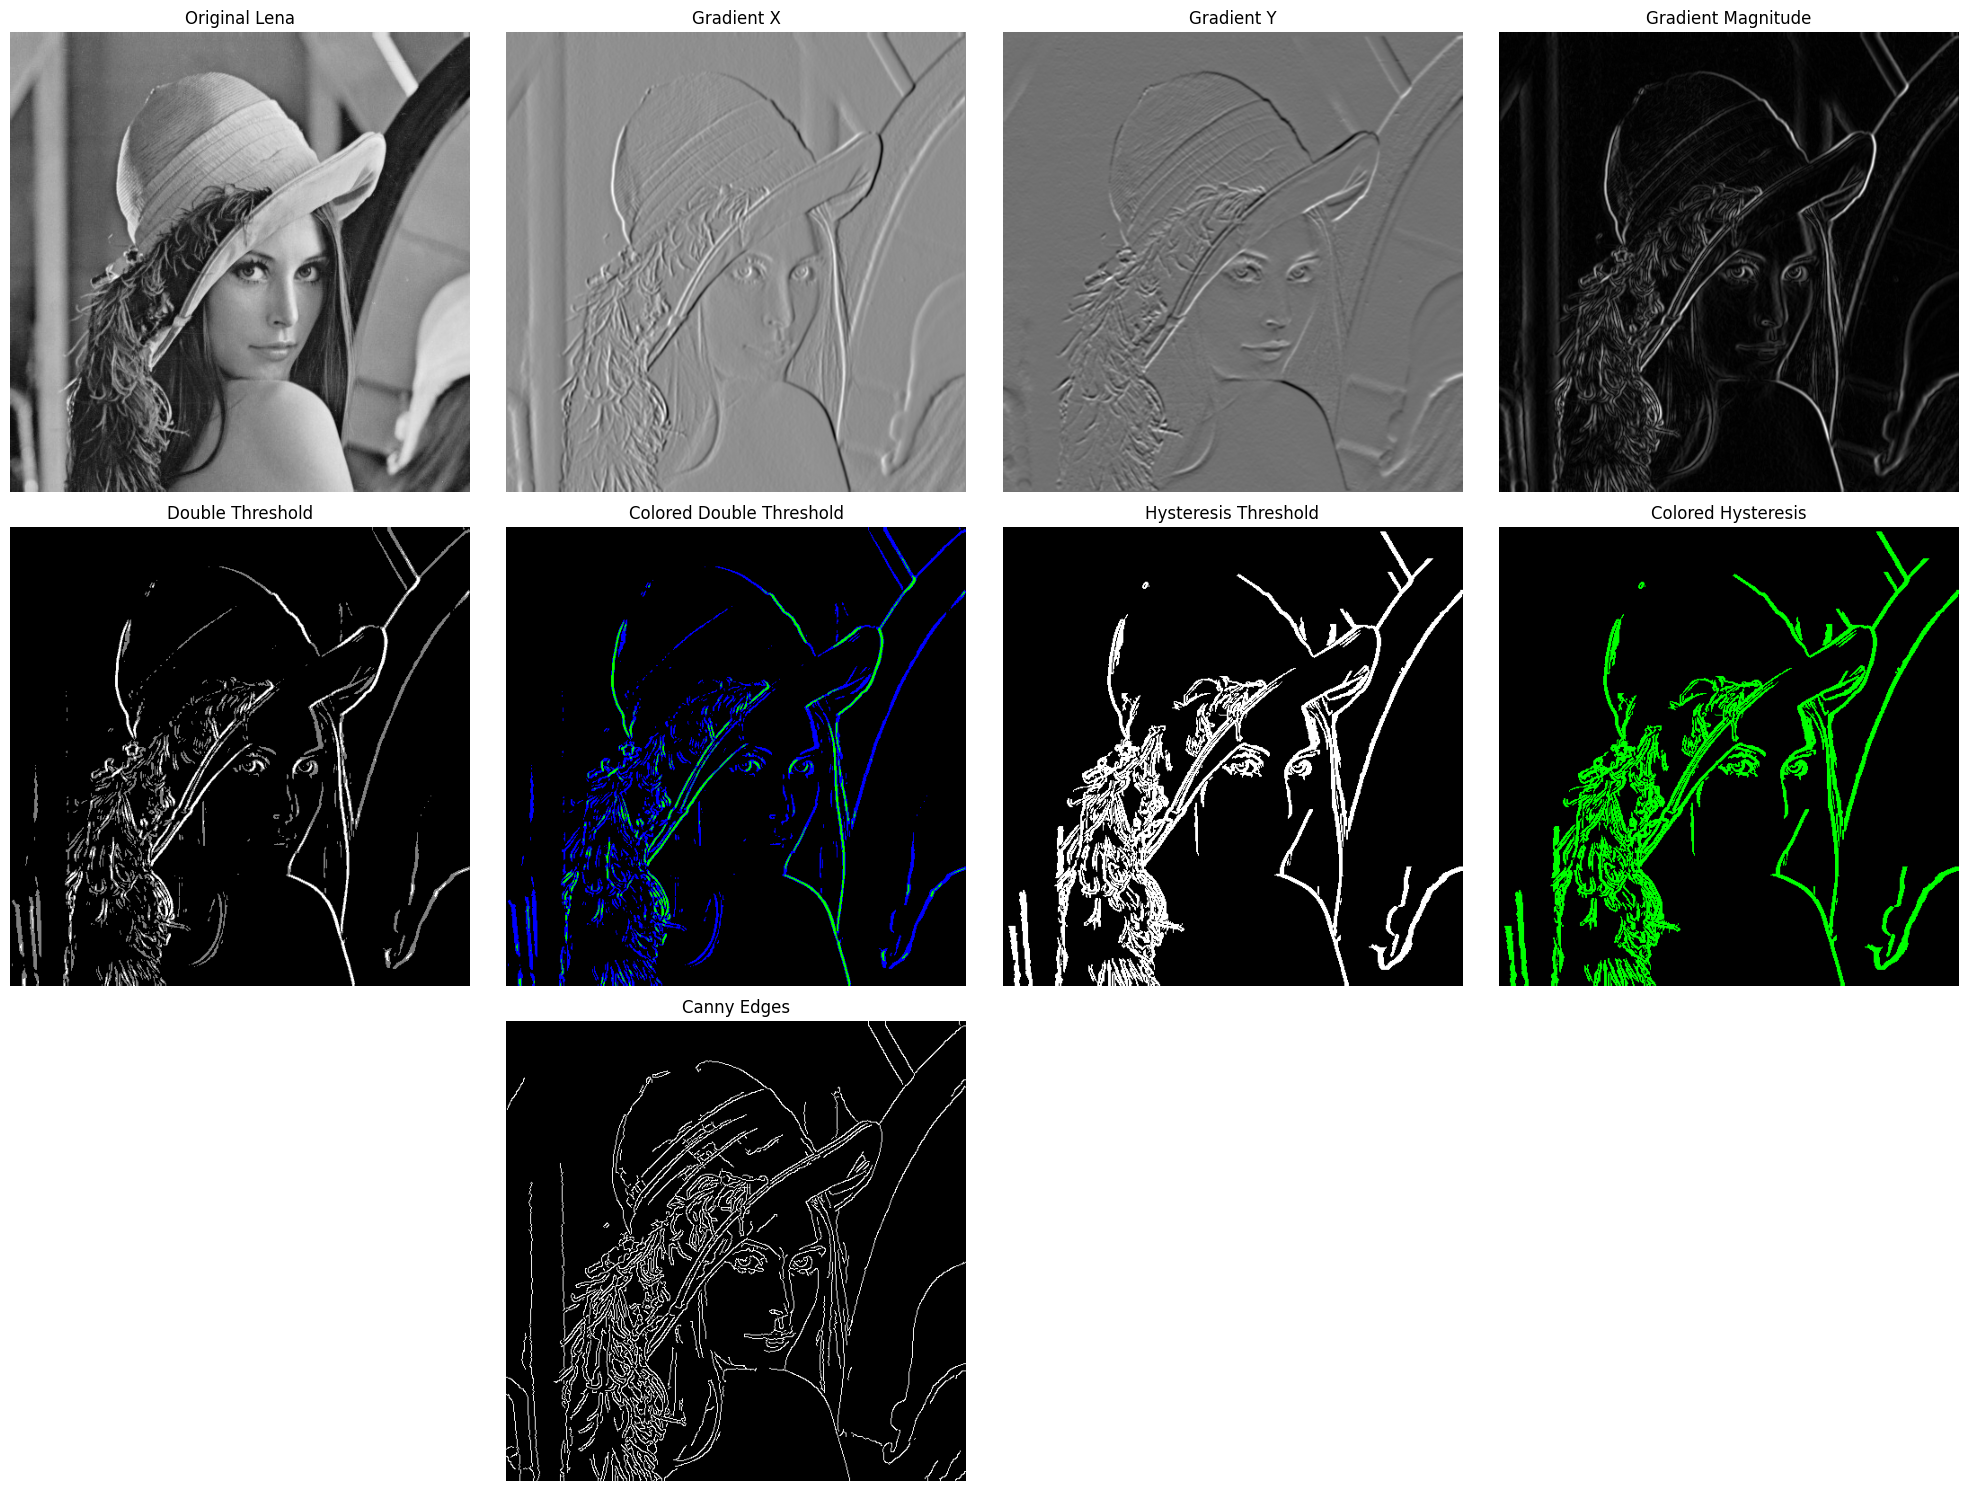

In [85]:
plt.figure(figsize=(20, 15))

plt.subplot(3, 4, 1)
plt.imshow(lena, cmap='gray')
plt.title('Original Lena')
plt.axis('off')

plt.subplot(3, 4, 2)
plt.imshow(norm_x, cmap='gray')
plt.title('Gradient X')
plt.axis('off')

plt.subplot(3, 4, 3)
plt.imshow(norm_y, cmap='gray')
plt.title('Gradient Y')
plt.axis('off')

plt.subplot(3, 4, 4)
plt.imshow(grad_norm, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.subplot(3, 4, 5)
plt.imshow(apply_double_threshold, cmap='gray')
plt.title('Double Threshold')
plt.axis('off')

plt.subplot(3, 4, 6)
colored_double_rgb = cv2.cvtColor(colored_double, cv2.COLOR_BGR2RGB)
plt.imshow(colored_double_rgb)
plt.title('Colored Double Threshold')
plt.axis('off')

plt.subplot(3, 4, 7)
plt.imshow(apply_hysteresis, cmap='gray')
plt.title('Hysteresis Threshold')
plt.axis('off')

plt.subplot(3, 4, 8)
colored_hysteresis_rgb = cv2.cvtColor(colored_hysteresis, cv2.COLOR_BGR2RGB)
plt.imshow(colored_hysteresis_rgb)
plt.title('Colored Hysteresis')
plt.axis('off')


plt.subplot(3, 4, 10)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges')
plt.axis('off')


plt.tight_layout()
plt.show()